In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d.axes3d import Axes3D
import subprocess

plt.rcParams.update({
    # "text.usetex": True,
    "font.family": "serif",
})

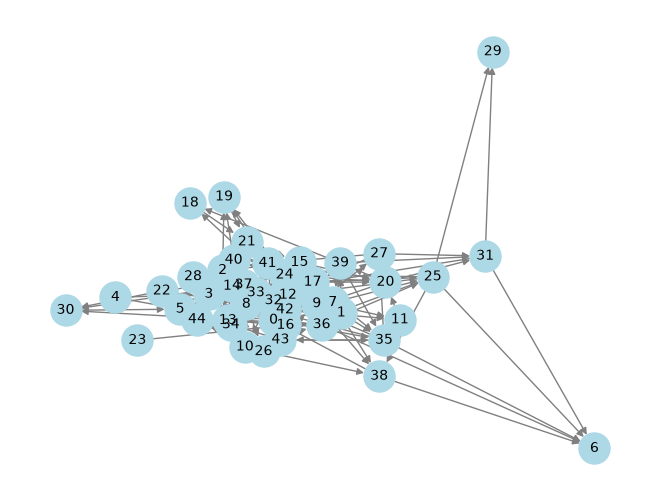

In [2]:
N = 45
# Generate random directed graph. Kept small and moderately connected so that
# individual edge directions stay readable in the figure.
graph = nx.erdos_renyi_graph(N, 0.06, directed=True, seed=7)

# Plot the graph
nx.draw(graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=10)

In [3]:
# Reproducibility
rng = np.random.default_rng(7)

# -----------------------------
# 1. Surface
# -----------------------------
x = np.linspace(-3.2, 3.2, 180)
y = np.linspace(-2.4, 2.4, 150)
X, Y = np.meshgrid(x, y)

R = np.sqrt((X / 1.15) ** 2 + (Y / 0.9) ** 2)

# A smooth "potato-chip" surface with a few broad features
Z = (
    0.38 * np.sin(1.15 * X + 0.35 * np.cos(Y))
    * np.cos(1.25 * Y)
    + 0.16 * np.exp(-((X + 1.1) ** 2 + (Y - 0.35) ** 2) / 0.65)
    - 0.20 * np.exp(-((X - 0.85) ** 2 + (Y + 0.55) ** 2) / 0.55)
    + 0.07 * np.cos(0.8 * X * Y)
)

# -----------------------------
# 2. Smooth random vector field
# -----------------------------
# Start with white noise and smooth it spatially.
noise_u = rng.normal(size=X.shape)
noise_v = rng.normal(size=Y.shape)

U = gaussian_filter(noise_u, sigma=13, mode="reflect")
V = gaussian_filter(noise_v, sigma=13, mode="reflect")

# Normalize the field while preserving its smooth structure.
speed = np.hypot(U, V)
U /= speed.max()
V /= speed.max()

# Add a weak rotational component for a more structured flow.
swirl = np.exp(-(X**2 + Y**2) / 5.0)
U += -0.22 * Y * swirl
V +=  0.22 * X * swirl

# Normalize again
speed = np.hypot(U, V)
U /= np.maximum(speed, 1e-12)
V /= np.maximum(speed, 1e-12)

# -----------------------------
# 3. Tangent vectors on the surface
# -----------------------------
# Surface gradients
dZdy, dZdx = np.gradient(Z, y, x)

# A horizontal vector (U, V, 0) projected onto the tangent plane:
# T = (U, V, 0) - [(U,V,0)·n] n
# with n proportional to (-dZdx, -dZdy, 1).
W = U * dZdx + V * dZdy
denom = 1.0 + dZdx**2 + dZdy**2

Tx = U - W * (-dZdx) / denom
Ty = V - W * (-dZdy) / denom
Tz = W / denom

# Normalize tangent vectors
Tnorm = np.sqrt(Tx**2 + Ty**2 + Tz**2)
Tx /= np.maximum(Tnorm, 1e-12)
Ty /= np.maximum(Tnorm, 1e-12)
Tz /= np.maximum(Tnorm, 1e-12)


In [4]:
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)


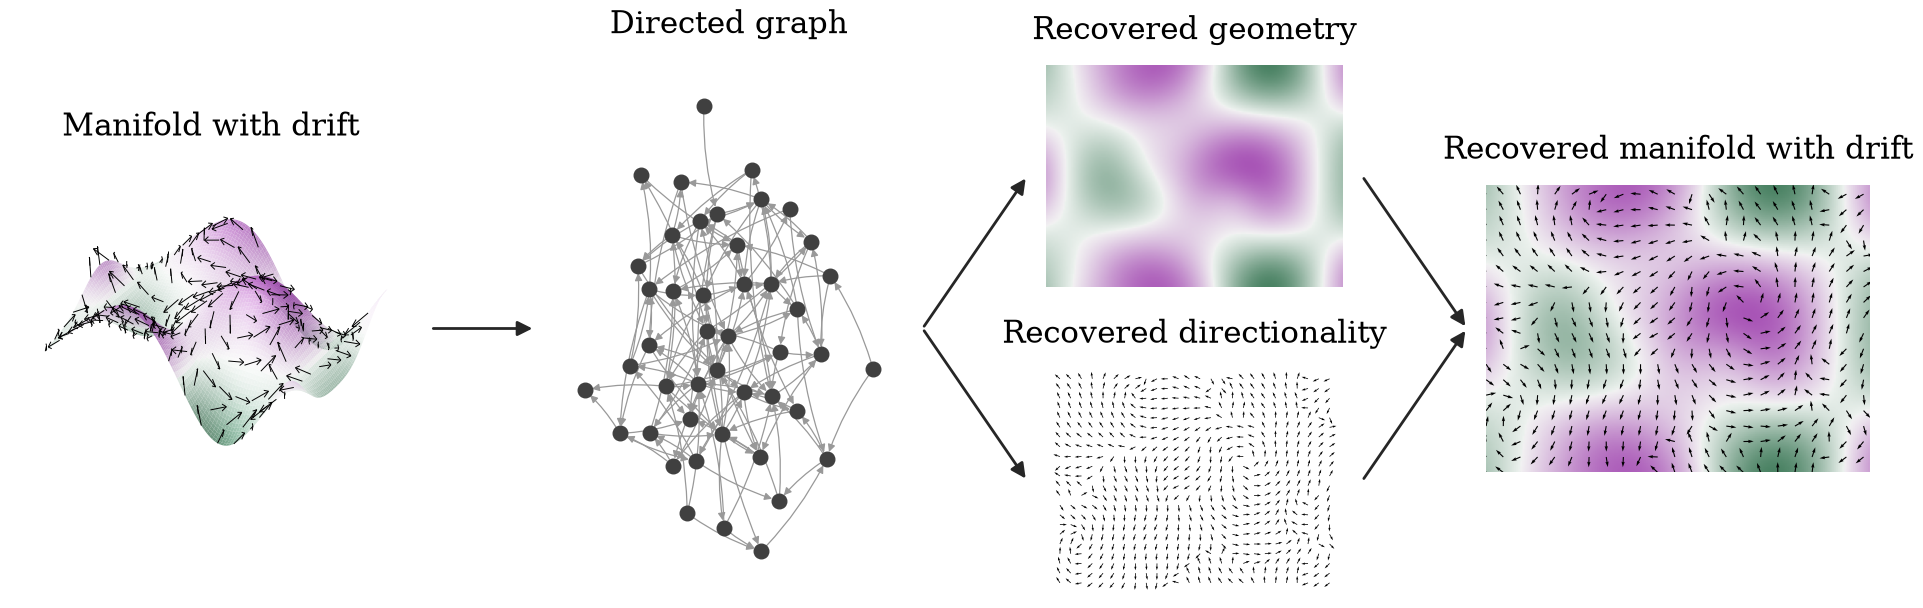

In [5]:
import matplotlib.patches as mpatches

def plot_surface(X,Y,Z,ax: Axes3D,use_wireframe: bool = True, zorder: int = 1):
    # 3D axes don't sort artists by depth correctly when mixing surfaces and
    # quivers; disabling automatic z-ordering lets us control it explicitly.
    ax.computed_zorder = False

    # Soft scientific lighting
    ls = LightSource(azdeg=315, altdeg=45)
    rgb = ls.shade(
        Z,
        cmap=cmap,
        vert_exag=0.7,
        blend_mode="soft",
    )

    if use_wireframe:
        ax.plot_wireframe(
            X, Y, Z,
            rstride=5,
            cstride=5,
            linewidth=0.5,
            antialiased=True,
            # alpha=0.96,
            color="black",
            zorder=zorder,
        )
    else:
        ax.plot_surface(
            X, Y, Z,
            facecolors=rgb,
            rstride=2,
            cstride=2,
            linewidth=0,
            antialiased=True,
            shade=False,
            alpha=0.8,
            zorder=zorder,
        )

def plot_arrows(X,Y,Z,Tx,Ty,Tz,ax: plt.Axes,skip: int = 7, arrow_scale: float = 0.30, color="black", zorder: int = 5):
    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        Z[::skip, ::skip],
        arrow_scale * Tx[::skip, ::skip],
        arrow_scale * Ty[::skip, ::skip],
        arrow_scale * Tz[::skip, ::skip],
        color=color,
        linewidth=0.7,
        arrow_length_ratio=0.28,
        normalize=False,
        zorder=zorder,
    )

def plot_drift_2d(X,Y,Tx,Ty,ax: plt.Axes,skip: int = 7, arrow_scale: float = 0.30, color="black"):
    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        arrow_scale * Tx[::skip, ::skip],
        arrow_scale * Ty[::skip, ::skip],
        color=color,
        linewidth=0.7,
    )
    ax.axis("off")
    ax.set_aspect("equal")

def plot_embedding_2d(X,Y,Z,ax: plt.Axes):
    ax.imshow(
        Z,
        cmap=cmap,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        origin="lower",
    )
    ax.axis("off")
    ax.set_aspect("equal")

def plot_graph(graph, ax: plt.Axes, node_size: int = 110):
    # Kamada-Kawai spreads the nodes evenly and is deterministic, so the panel
    # is identical from one run to the next; spring_layout clumped and drifted.
    pos = nx.kamada_kawai_layout(graph)
    nx.draw(
        graph,
        pos=pos,
        with_labels=False,
        node_color="0.25",
        edge_color="0.6",
        node_size=node_size,
        width=0.9,
        ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=11,
        # A slight curve separates the two edges of a reciprocal pair.
        connectionstyle="arc3,rad=0.08",
    )

def plot_labels(ax: Axes3D):
    # ax.set_xlabel(r"$x$", labelpad=8, fontsize=13)
    # ax.set_ylabel(r"$y$", labelpad=8, fontsize=13)
    # ax.set_zlabel(r"$f(x,y)$", labelpad=8, fontsize=13)

    ax.set_box_aspect((1.35, 1.0, 0.55))
    ax.view_init(elev=32, azim=-58)

    # Remove panes and grid for a cleaner appearance
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor("none")

    # ax.tick_params(axis="both", which="major", labelsize=10)
    # ax.tick_params(axis="z", which="major", labelsize=9)
    ax.axis("off")

# -----------------------------
# 4. Plot: manifold with drift -> directed graph -> {geometry, drift} -> merged embedding
# -----------------------------
fig = plt.figure(figsize=(24, 7.0))
gs = fig.add_gridspec(2, 4, width_ratios=[1.15, 1.0, 0.85, 1.1], wspace=0.40, hspace=0.30)

# Stage 1: ground-truth manifold with drift
ax_manifold = fig.add_subplot(gs[:, 0], projection="3d")
plot_surface(X, Y, Z, ax_manifold, use_wireframe=False, zorder=1)
plot_arrows(X, Y, Z, Tx, Ty, Tz, ax_manifold, skip=12, arrow_scale=0.38, zorder=5)
plot_labels(ax_manifold)

# Stage 2: directed graph
ax_graph = fig.add_subplot(gs[:, 1])
plot_graph(graph, ax_graph)

# Stage 3a: recovered geometry -> 2D embedding
ax_geom = fig.add_subplot(gs[0, 2])
plot_embedding_2d(X, Y, Z, ax_geom)

# Stage 3b: recovered directionality -> 2D drift field
ax_dir = fig.add_subplot(gs[1, 2])
plot_drift_2d(X, Y, Tx, Ty, ax_dir, skip=7, arrow_scale=0.30)

# Stage 4: the two recovered components put back together
ax_merged = fig.add_subplot(gs[:, 3])
plot_embedding_2d(X, Y, Z, ax_merged)
plot_drift_2d(X, Y, Tx, Ty, ax_merged, skip=8, arrow_scale=0.32)

fig.canvas.draw()  # settle the layout before measuring the panels
renderer = fig.canvas.get_renderer()

def content_bbox(ax):
    """Bbox of what is actually drawn in `ax`, in figure coordinates, title excluded.

    Equal-aspect images and projected 3D surfaces are smaller than their grid
    cell, so the cell itself is a poor anchor for titles and arrows.
    """
    was_visible = ax.title.get_visible()
    ax.title.set_visible(False)
    bb = ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
    ax.title.set_visible(was_visible)
    return bb

def place_title(ax, text, fontsize: int = 22, pad: float = 0.025):
    """Set a title sitting just above the drawn content rather than the grid cell."""
    bb, pos = content_bbox(ax), ax.get_position()
    ax.set_title(text, fontsize=fontsize, y=(bb.y1 + pad - pos.y0) / pos.height)

def connect(ax_from, ax_to, gap: float = 0.008):
    """Draw a figure-level arrow between the drawn content of two axes."""
    bb_from, bb_to = content_bbox(ax_from), content_bbox(ax_to)
    pos_from, pos_to = ax_from.get_position(), ax_to.get_position()

    arrow = mpatches.FancyArrowPatch(
        (bb_from.x1 + gap, (pos_from.y0 + pos_from.y1) / 2),
        (bb_to.x0 - gap, (pos_to.y0 + pos_to.y1) / 2),
        transform=fig.transFigure,
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=2.0,
        color="0.15",
        connectionstyle="arc3,rad=0.0",
        clip_on=False,
        zorder=10,
    )
    fig.add_artist(arrow)

connect(ax_manifold, ax_graph)
connect(ax_graph, ax_geom)
connect(ax_graph, ax_dir)
connect(ax_geom, ax_merged)
connect(ax_dir, ax_merged)

place_title(ax_manifold, "Manifold with drift")
place_title(ax_graph, "Directed graph")
place_title(ax_geom, "Recovered geometry")
place_title(ax_dir, "Recovered directionality")
place_title(ax_merged, "Recovered manifold with drift")

plt.savefig("algo_illustration.pdf", bbox_inches="tight")
plt.show()


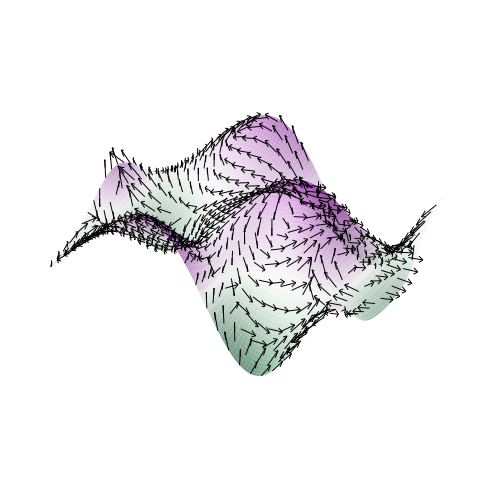

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `fig1_1_cropped.pdf'.


CompletedProcess(args=['pdfcrop', 'fig1_1.pdf', 'fig1_1_cropped.pdf'], returncode=0)

In [6]:
fig = plt.figure(figsize=(6,6))
ax_arrows = fig.add_subplot(111, projection="3d")
plot_surface(X, Y, Z, ax_arrows,use_wireframe=False)
plot_arrows(X, Y, Z, Tx, Ty, Tz, ax_arrows, skip=7, arrow_scale=0.30)
plot_labels(ax_arrows)
plt.savefig("fig1_1.pdf", dpi=300,pad_inches=0.00,bbox_inches="tight")
plt.show()
subprocess.run([
    "pdfcrop",
    "fig1_1.pdf",
    "fig1_1_cropped.pdf",
], check=True)


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `fig1_2_cropped.pdf'.


CompletedProcess(args=['pdfcrop', 'fig1_2.pdf', 'fig1_2_cropped.pdf'], returncode=0)

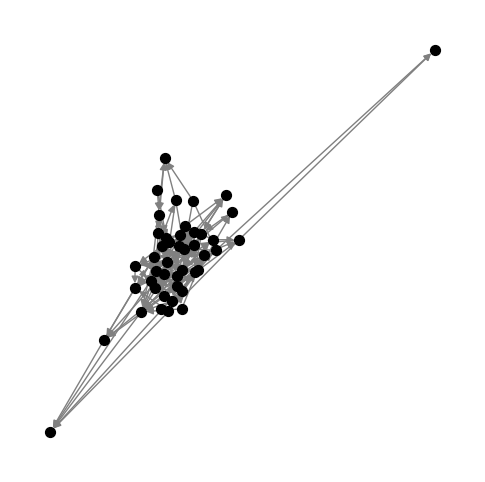

In [7]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
nx.draw(graph, with_labels=False, node_color='black', edge_color='gray', ax=ax,node_size=50)
plt.savefig("fig1_2.pdf", dpi=300,pad_inches=0.00,bbox_inches="tight")
subprocess.run([
    "pdfcrop",
    "fig1_2.pdf",
    "fig1_2_cropped.pdf",
], check=True)

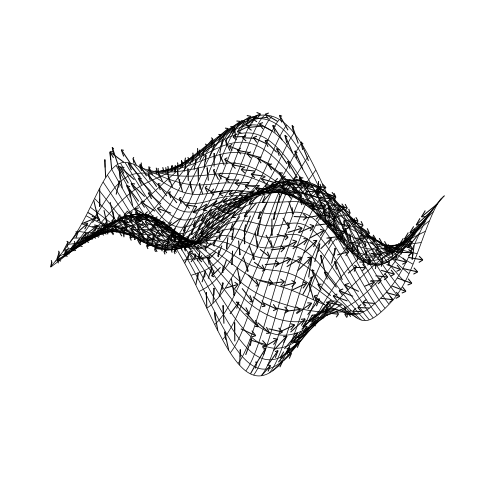

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `fig1_3_cropped.pdf'.


CompletedProcess(args=['pdfcrop', 'fig1_3.pdf', 'fig1_3_cropped.pdf'], returncode=0)

In [8]:
fig = plt.figure(figsize=(6,6))
ax_arrows = fig.add_subplot(111, projection="3d")
plot_surface(X, Y, Z, ax_arrows,use_wireframe=True)
plot_arrows(X, Y, Z, Tx, Ty, Tz, ax_arrows, skip=7, arrow_scale=0.30)
plot_labels(ax_arrows)
plt.savefig("fig1_3.pdf", dpi=300,pad_inches=0.00,bbox_inches="tight")
plt.show()
subprocess.run([
    "pdfcrop",
    "fig1_3.pdf",
    "fig1_3_cropped.pdf",
], check=True)


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `fig1_3_cropped.pdf'.


CompletedProcess(args=['pdfcrop', 'fig1_3.pdf', 'fig1_3_cropped.pdf'], returncode=0)

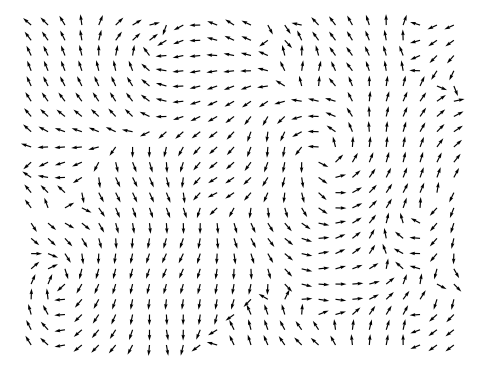

In [9]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.quiver(
    X[::7, ::7],
    Y[::7, ::7],
    0.30 * Tx[::7, ::7],
    0.30 * Ty[::7, ::7],
    color="black",
)
ax.axis("off")
ax.set_aspect("equal")
plt.savefig("fig1_3.pdf", bbox_inches="tight")
subprocess.run([
    "pdfcrop",
    "fig1_3.pdf",
    "fig1_3_cropped.pdf",
], check=True)

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.


==> 1 page written on `fig1_4_cropped.pdf'.


CompletedProcess(args=['pdfcrop', 'fig1_4.pdf', 'fig1_4_cropped.pdf'], returncode=0)

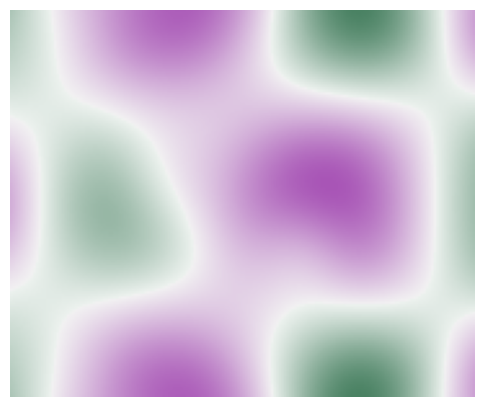

In [10]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.imshow(Z, cmap=cmap, origin="lower")
ax.axis("off")
ax.set_aspect("equal")
plt.savefig("fig1_4.pdf", bbox_inches="tight")
subprocess.run([
    "pdfcrop",
    "fig1_4.pdf",
    "fig1_4_cropped.pdf",
], check=True)

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `fig1_5_cropped.pdf'.


CompletedProcess(args=['pdfcrop', 'fig1_5.pdf', 'fig1_5_cropped.pdf'], returncode=0)

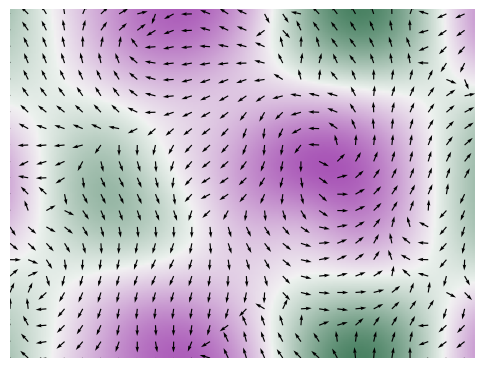

In [11]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.imshow(Z, cmap=cmap,extent=[x.min(), x.max(), y.min(), y.max()], origin="lower")
ax.quiver(
    X[::7, ::7],
    Y[::7, ::7],
    0.30 * Tx[::7, ::7],
    0.30 * Ty[::7, ::7],
    color="black",
)
ax.axis("off")
ax.set_aspect("equal")
plt.savefig("fig1_5.pdf", bbox_inches="tight")
subprocess.run([
    "pdfcrop",
    "fig1_5.pdf",
    "fig1_5_cropped.pdf",
], check=True)